In [1]:
# Внимание!!! Важно, что бы файлы с данными и исполняемый файл находились в одной папке, 
# тогда пути к тестовым и тренировочным наборам будут содержать только имена файлов.
# 
# В пути к тренировочным и тестовым данным запрежается использовать абсалютную адресацию, 
# то есть адресацию, в которой присутствуют имена папок. Путь должен содержать только имя файла.
#
# Напоминание: под моделью машинного обучения понимаются все действия с исходными данными, 
# которые необходимо произвести, что бы сопоставить признаки целевому значению.

### Область работы 1 (библиотеки)

In [3]:
# Данный блок в области 1 НЕ выполняется преподавателем
# 
# данный блок предназначен только для подключения необходимых библиотек
# запрещается подключать библиотеки в других блоках
#
# установка дополнительных библиотек размещается прямо здесь (обязательно закоментированы)
#
# pip install

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split,cross_val_score, GridSearchCV, KFold, StratifiedShuffleSplit, ParameterGrid,RandomizedSearchCV,cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer, TransformedTargetRegressor
from sklearn.metrics import fbeta_score, make_scorer

from sklearn.preprocessing import OrdinalEncoder,LabelEncoder, OneHotEncoder, TargetEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.preprocessing import PolynomialFeatures, QuantileTransformer, PowerTransformer
from sklearn.preprocessing import PolynomialFeatures
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer

from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.linear_model import HuberRegressor

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import category_encoders as ce

### Область работы 2 (поиск  модели .... )

In [6]:
# Данный блок(и) НЕ выполняются преподавателем в области 2
# блок(и) предназначены для поиска лучшей модели 
# должен быть понятен и очевиден отбор параметров модели
# 
# Запрещается размещать данные блоки за пределами обасти 2
# Все блоки данной области должны быть выполнены
#
# ЗАПРЕЩАЕТСЯ ИСПОЛЬЗОВАТЬ ТЕСТОВЫЙ НАБОР
#
# Путь к тренировочному набору
# 

path_train = 'train.csv' # содержит только имя файла, без имен папок !!!

In [7]:
df = pd.read_csv(path_train)
df.tail(3)

,carat,cut,color,clarity,depth,table,price,x,y,z
40452,0.42,Ideal,G,SI2,60.9,56.0,971,4.87,4.89,2.97
40453,2.05,Premium,E,SI2,59.7,59.0,17237,8.39,8.27,4.97
40454,0.55,Premium,H,VVS1,61.1,57.0,1980,5.35,5.26,3.24


In [8]:
duplicates = df[df.duplicated()]
print(df.duplicated().sum())

78


In [9]:
df = df.drop_duplicates()

In [10]:
display(df.info())
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 40377 entries, 0 to 40454
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    40377 non-null  float64
 1   cut      40377 non-null  object 
 2   color    40377 non-null  object 
 3   clarity  40377 non-null  object 
 4   depth    40377 non-null  float64
 5   table    40377 non-null  float64
 6   price    40377 non-null  int64  
 7   x        40377 non-null  float64
 8   y        40377 non-null  float64
 9   z        40377 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 3.4+ MB


None

,carat,depth,table,price,x,y,z
count,40377.00000,40377.000000,40377.000000,40377.000000,40377.000000,40377.000000,40377.000000
mean,0.79713,61.745600,57.452126,3938.759690,5.728777,5.732886,3.537583
std,0.47404,1.420043,2.231121,3998.041468,1.122689,1.152500,0.709028
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,946.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.690000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.000000,6.540000,6.530000,4.030000
max,5.01000,78.200000,95.000000,18818.000000,10.740000,58.900000,31.800000


In [11]:
# df['x'].value_counts().sort_index(ascending=False).head(5)

In [12]:
# df[df['z'].isin(df['z'].value_counts().sort_index(ascending=False).head(5).index)]

In [13]:
# df['y'].hist(bins=500)

In [14]:
df['x']=np.where(df['x']>=15, df['x']/10,df['x'])
df['y']=np.where(df['y']>=15, df['y']/10,df['y'])
df['z']=np.where(df['z']>=15, df['z']/10,df['z'])

In [15]:
# df.columns

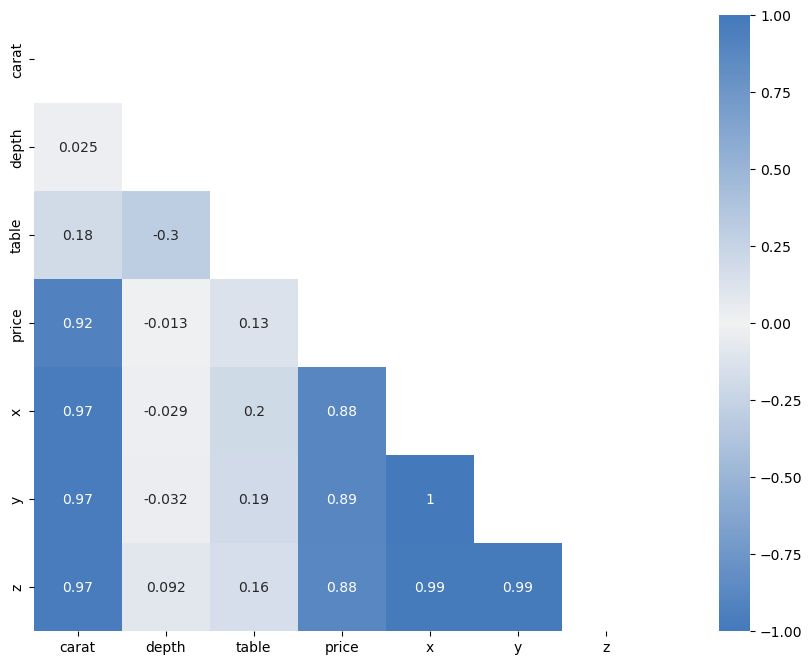

In [16]:
corr = df[['carat', 'depth', 'table', 'price', 'x', 'y','z']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(corr,
    mask=mask,
    cmap=sns.diverging_palette(250, 250, as_cmap=True),
    annot = True,
    vmin=-1.0, vmax=1.0,
    square=True,
    ax=ax);

In [17]:
df[df.eq(0).any(axis=1)]

,carat,cut,color,clarity,depth,table,price,x,y,z
4817,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
7928,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10418,2.02,Premium,H,VS2,62.7,53.0,18207,8.02,7.95,0.0
11203,2.25,Premium,I,SI1,61.3,58.0,15397,8.52,8.42,0.0
13661,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
15977,0.71,Good,F,SI2,64.1,60.0,2130,0.00,0.00,0.0
18359,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
23017,1.20,Premium,D,VVS1,62.1,59.0,15686,0.00,0.00,0.0
25662,1.56,Ideal,G,VS2,62.2,54.0,12800,0.00,0.00,0.0
32084,2.25,Premium,H,SI2,62.8,59.0,18034,0.00,0.00,0.0


In [18]:
df = df.drop(['depth'], axis=1)

In [19]:
cat_features = ['cut','color']
axis_features = ['x','y','z']
num_features = ['carat',  'table']

y = np.array(df.price)
X = df.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [20]:
axis_transformer = Pipeline(steps=[
    ('missing_num', IterativeImputer(missing_values=0, max_iter=5)),
    ('polynom', PolynomialFeatures(2,include_bias=False)),
    ('scaler', StandardScaler())])

num = Pipeline(steps=[
    ('missing_num', IterativeImputer(missing_values=0, max_iter=5)),
    ('scaler', StandardScaler())])

clarity_map = [{
    'col':'clarity',
    'mapping':{'IF':7, 'VVS1':6, 'VVS2':5, 'VS1':4, 'VS2':3, 
               'SI1':2, 'SI2':1, 'I1':0}
    }]

clarity_transformer = Pipeline(steps=[
    ('missing_num', SimpleImputer(strategy = 'most_frequent')),
    ('ce',ce.OrdinalEncoder(mapping=clarity_map)),
    ('scaler', MinMaxScaler())
    ])    
    
CT = ColumnTransformer([
        ("axis_transformer", axis_transformer, axis_features),
        ("num", num, num_features),
        # убрать быстую разряженную 
        ("cat", OneHotEncoder(sparse_output=False, drop='first'), cat_features),
        ("ordinal_map", clarity_transformer, ['clarity'])
      ], remainder='passthrough').set_output(transform='pandas')

display(CT)

ct = CT.fit_transform(X_train)
pd.DataFrame(ct).head().T

ColumnTransformer(remainder='passthrough',
                  transformers=[('axis_transformer',
                                 Pipeline(steps=[('missing_num',
                                                  IterativeImputer(max_iter=5,
                                                                   missing_values=0)),
                                                 ('polynom',
                                                  PolynomialFeatures(include_bias=False)),
                                                 ('scaler', StandardScaler())]),
                                 ['x', 'y', 'z']),
                                ('num',
                                 Pipeline(steps=[('missing_num',
                                                  IterativeImputer(max_iter=5,
                                                                   missing_values=0)),
                                                 ('scaler', Stand...),
                                 ['carat', 'table']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               sparse_output=False),
                                 ['cut', 'color']),
                                ('ordinal_map',
                                 Pipeline(steps=[('missing_num',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ce',
                                                  OrdinalEncoder(mapping=[{'col': 'clarity',
                                                                           'data_type': dtype('O'),
                                                                           'mapping': IF      7
VVS1    6
VVS2    5
VS1     4
VS2     3
SI1     2
SI2     1
I1      0
dtype: int64}])),
                                                 ('scaler', MinMaxScaler())]),
                                 ['clarity'])])

,18095,30532,13942,28863,23320
axis_transformer__x,2.590474,0.114566,-0.466423,1.276545,-0.841831
axis_transformer__y,2.581439,0.150012,-0.498369,1.257662,-0.894601
axis_transformer__z,2.505676,0.001682,-0.490432,1.564869,-0.895703
axis_transformer__x^2,3.014499,0.017480,-0.519801,1.281331,-0.833412
axis_transformer__x y,3.008803,0.035290,-0.533716,1.271138,-0.854979
axis_transformer__x z,2.963924,-0.037002,-0.531064,1.459452,-0.856831
axis_transformer__y^2,3.000330,0.053058,-0.547508,1.259588,-0.876097
axis_transformer__y z,2.958091,-0.019815,-0.545056,1.449225,-0.878382
axis_transformer__z^2,2.891449,-0.091822,-0.540370,1.633160,-0.875783
num__carat,3.363542,-0.142626,-0.565056,1.483729,-0.839635


In [21]:
def plot_2_error(y_true, y_predicted):
    residuals = (y_true - y_predicted)/y_predicted
    max_error = max(residuals) if abs(max(residuals)) > abs(min(residuals)) else min(residuals)
    max_idx = list(residuals).index(max(residuals)) if abs(max(residuals)) > abs(min(residuals)) else list(residuals).index(min(residuals))
    max_true, max_pred = y_true[max_idx], y_predicted[max_idx]
    mape = mean_squared_error(y_true, y_predicted)
    print("Max Error:", "{:,.0f}".format(max_error))
    print(' ')
    print('----------------------')
    print("   MSE Error:", "{:,.2f}".format(mape*100))
    print('----------------------')

    ## Plot predicted vs true
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
    from statsmodels.graphics.api import abline_plot
    ax[0].scatter(y_predicted, y_true, color="black", alpha=0.25)
    abline_plot(intercept=0, slope=1, color="red", ax=ax[0])
    ax[0].vlines(x=max_pred, ymin=max_true, ymax=max_true-max_error, color='red', linestyle='--', alpha=0.7, label="max error")
    ax[0].grid(True)
    ax[0].set(xlabel="Predicted", ylabel="True", title="Predicted vs True")
    ax[0].legend()

    ## Plot predicted vs residuals
    ax[1].scatter(y_predicted, residuals, color="red", alpha=0.25)
    ax[1].vlines(x=max_pred, ymin=0, ymax=max_error, color='black', linestyle='--', alpha=0.7, label="max error")
    ax[1].grid(True)
    ax[1].set(xlabel="Predicted", ylabel="Residuals", title="Predicted vs Residuals")
    ax[1].hlines(y=0, xmin=np.min(y_predicted), xmax=np.max(y_predicted))
    ax[1].legend()
    plt.show()

In [22]:
def mse_irq(y_true, y_pred):
    delta = y_pred - y_true
    q_25 = np.quantile(delta, 0.25)
    q_75 = np.quantile(delta, 0.75)
    irq = q_75 - q_25
    mask = (delta < q_25 - 1.5*irq) | (delta > q_75 + 1.5*irq)
    if delta[mask].sum() == 0:
        results = 0
    else:
        results = -np.sum((delta[mask])**2)/len(delta[mask])
    return results


**Huber Regression**

In [24]:
model_pipe_hub = Pipeline([
                ('model', TransformedTargetRegressor(
                        regressor = Pipeline(steps=[
                                ('preproc', CT),
                                ('estimator', HuberRegressor())
                            ]),
                        transformer=PowerTransformer(),
                        check_inverse = False)
                )])
model_pipe_hub.fit(X_train, y_train)

C:\Users\zvlad\anaconda3\Lib\site-packages\sklearn\linear_model\_huber.py:342: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Pipeline(steps=[('model',
                 TransformedTargetRegressor(check_inverse=False,
                                            regressor=Pipeline(steps=[('preproc',
                                                                       ColumnTransformer(remainder='passthrough',
                                                                                         transformers=[('axis_transformer',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         IterativeImputer(max_iter=5,
                                                                                                                                          missing_values=0)),
                                                                                                                        ('polynom',
                                                                                                                         PolynomialFeatures(include_bias=False)),
                                                                                                                        ('scaler',
                                                                                                                         StandardScaler())]),
                                                                                                        ['x',
                                                                                                         '...
                                                                                                                      sparse_output=False),
                                                                                                        ['cut',
                                                                                                         'color']),
                                                                                                       ('ordinal_map',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         SimpleImputer(strategy='most_frequent')),
                                                                                                                        ('ce',
                                                                                                                         OrdinalEncoder(mapping=[{'col': 'clarity',
                                                                                                                                                  'data_type': dtype('O'),
                                                                                                                                                  'mapping': IF      7
VVS1    6
VVS2    5
VS1     4
VS2     3
SI1     2
SI2     1
I1      0
dtype: int64}])),
                                                                                                                        ('scaler',
                                                                                                                         MinMaxScaler())]),
                                                                                                        ['clarity'])])),
                                                                      ('estimator',
                                                                       HuberRegressor())]),
                                            transformer=PowerTransformer()))])

In [25]:
print(model_pipe_hub.score(X_train, y_train))
print(model_pipe_hub.score(X_test, y_test))

0.9503337992691756
0.9515347569475625


Max Error: 2
 
----------------------
   MSE Error: 78,357,474.04
----------------------


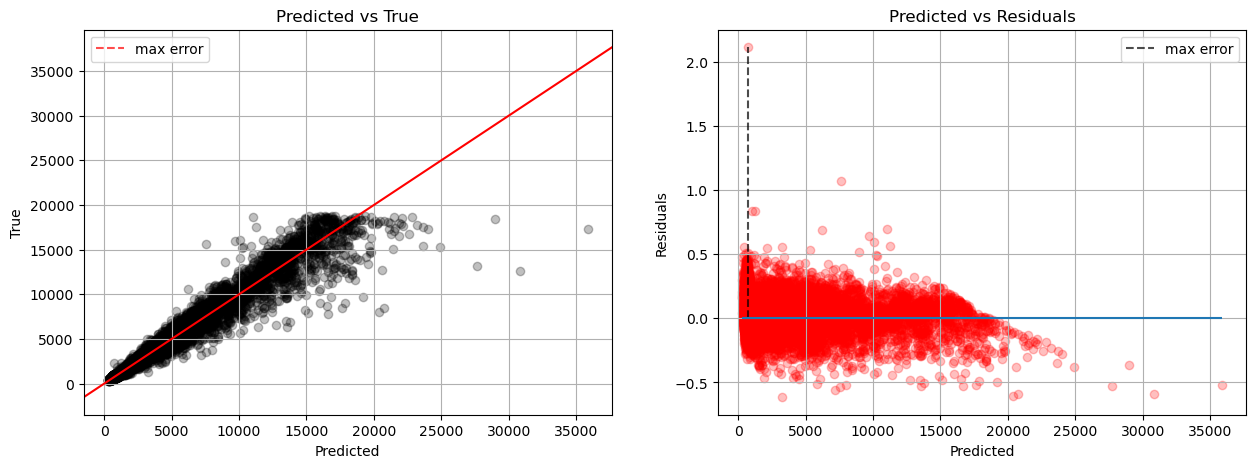

In [26]:
plot_2_error(y_test, model_pipe_hub.predict(X_test))

In [27]:
print(mse_irq(y_test, model_pipe_hub.predict(X_test)))
print(mean_squared_error(y_test, model_pipe_hub.predict(X_test)))

-4329354.998035867
783574.7404049719


**KNN**

In [29]:
model_pipel = Pipeline([
                ('model', TransformedTargetRegressor(
                        regressor = Pipeline(steps=[
                                ('preproc', CT),
                                ('estimator', KNeighborsRegressor())
                            ]),
                        transformer=QuantileTransformer(n_quantiles=1000, output_distribution="uniform"),
                        check_inverse = False)
                )])
model_pipel.fit(X_train, y_train)

Pipeline(steps=[('model',
                 TransformedTargetRegressor(check_inverse=False,
                                            regressor=Pipeline(steps=[('preproc',
                                                                       ColumnTransformer(remainder='passthrough',
                                                                                         transformers=[('axis_transformer',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         IterativeImputer(max_iter=5,
                                                                                                                                          missing_values=0)),
                                                                                                                        ('polynom',
                                                                                                                         PolynomialFeatures(include_bias=False)),
                                                                                                                        ('scaler',
                                                                                                                         StandardScaler())]),
                                                                                                        ['x',
                                                                                                         '...
                                                                                                        ['cut',
                                                                                                         'color']),
                                                                                                       ('ordinal_map',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         SimpleImputer(strategy='most_frequent')),
                                                                                                                        ('ce',
                                                                                                                         OrdinalEncoder(mapping=[{'col': 'clarity',
                                                                                                                                                  'data_type': dtype('O'),
                                                                                                                                                  'mapping': IF      7
VVS1    6
VVS2    5
VS1     4
VS2     3
SI1     2
SI2     1
I1      0
dtype: int64}])),
                                                                                                                        ('scaler',
                                                                                                                         MinMaxScaler())]),
                                                                                                        ['clarity'])])),
                                                                      ('estimator',
                                                                       KNeighborsRegressor())]),
                                            transformer=QuantileTransformer()))])

In [30]:
param_grid = [
    {'model__regressor__preproc__num__scaler': [StandardScaler(), RobustScaler()],
     'model__regressor__preproc__ordinal_map__ce':[ce.OrdinalEncoder(mapping=clarity_map), TargetEncoder()],
     'model__regressor__estimator':[KNeighborsRegressor()],
     'model__regressor__estimator__n_neighbors': [3,4,5],
     'model__regressor__estimator__p':[1,2],
     'model__transformer':[PowerTransformer(),QuantileTransformer(n_quantiles=1000, output_distribution="uniform")]},
]
    
scores='neg_mean_absolute_percentage_error'
grid_1 = GridSearchCV(model_pipel, n_jobs=-1, param_grid=param_grid, scoring=scores)
grid_1.fit(X_train, y_train)

GridSearchCV(estimator=Pipeline(steps=[('model',
                                        TransformedTargetRegressor(check_inverse=False,
                                                                   regressor=Pipeline(steps=[('preproc',
                                                                                              ColumnTransformer(remainder='passthrough',
                                                                                                                transformers=[('axis_transformer',
                                                                                                                               Pipeline(steps=[('missing_num',
                                                                                                                                                IterativeImputer(max_iter=5,
                                                                                                                                                                 missing_values=0)),
                                                                                                                                               ('polynom',
                                                                                                                                                PolynomialFeatures(include_bias=False)),
                                                                                                                                               ('scaler',
                                                                                                                                                Sta...
                          'model__regressor__preproc__num__scaler': [StandardScaler(),
                                                                     RobustScaler()],
                          'model__regressor__preproc__ordinal_map__ce': [OrdinalEncoder(mapping=[{'col': 'clarity',
                                                                                                  'data_type': dtype('O'),
                                                                                                  'mapping': IF      7
VVS1    6
VVS2    5
VS1     4
VS2     3
SI1     2
SI2     1
I1      0
dtype: int64}]),
                                                                         TargetEncoder()],
                          'model__transformer': [PowerTransformer(),
                                                 QuantileTransformer()]}],
             scoring='neg_mean_absolute_percentage_error')

In [31]:
grid_result = pd.DataFrame(grid_1.cv_results_).sort_values(["rank_test_score",'std_test_score']).T
grid_result

,28,44,12,29,45,13,24,8,40,25,...,33,43,39,7,18,19,34,2,35,3
mean_fit_time,0.375646,0.401442,0.312806,0.284992,0.297673,0.315054,0.342577,0.3236,0.281205,0.358401,...,0.483868,0.296387,0.271237,0.283492,0.271346,0.272831,0.554137,0.265545,0.339623,0.232572
std_fit_time,0.04871,0.077012,0.011313,0.043542,0.065368,0.018962,0.022971,0.035386,0.025921,0.051437,...,0.071778,0.042968,0.047754,0.061432,0.019826,0.033368,0.201461,0.011376,0.051103,0.025361
mean_score_time,1.578368,1.532228,1.680182,1.428392,1.373896,1.641441,1.64906,1.318421,1.378358,1.777446,...,7.239793,1.682637,6.334374,6.136719,6.512922,5.882121,7.603442,5.939033,8.178471,6.430802
std_score_time,0.078955,0.050147,0.020793,0.080464,0.025572,0.11308,0.160155,0.022172,0.025739,0.200959,...,0.412974,0.055138,0.686249,0.112935,0.479836,0.483533,0.476115,0.166952,0.43084,0.182272
param_model__regressor__estimator,KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),...,KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor(),KNeighborsRegressor()
param_model__regressor__estimator__n_neighbors,4,5,3,4,5,3,4,3,5,4,...,5,5,5,3,4,4,5,3,5,3
param_model__regressor__estimator__p,2,2,2,2,2,2,2,2,2,2,...,1,2,1,1,1,1,1,1,1,1
param_model__regressor__preproc__num__scaler,RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),RobustScaler(),StandardScaler(),StandardScaler(),StandardScaler(),StandardScaler(),...,StandardScaler(),StandardScaler(),RobustScaler(),RobustScaler(),StandardScaler(),StandardScaler(),StandardScaler(),StandardScaler(),StandardScaler(),StandardScaler()
param_model__regressor__preproc__ordinal_map__ce,"OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...","OrdinalEncoder(mapping=[{'col': 'clarity', 'da...",...,"OrdinalEncoder(mapping=[{'col': 'clarity', 'da...",TargetEncoder(),TargetEncoder(),TargetEncoder(),TargetEncoder(),TargetEncoder(),TargetEncoder(),TargetEncoder(),TargetEncoder(),TargetEncoder()
param_model__transformer,PowerTransformer(),PowerTransformer(),PowerTransformer(),QuantileTransformer(),QuantileTransformer(),QuantileTransformer(),PowerTransformer(),PowerTransformer(),PowerTransformer(),QuantileTransformer(),...,QuantileTransformer(),QuantileTransformer(),QuantileTransformer(),QuantileTransformer(),PowerTransformer(),QuantileTransformer(),PowerTransformer(),PowerTransformer(),QuantileTransformer(),QuantileTransformer()


In [32]:
best_knn = grid_1.best_estimator_
best_knn.fit(X_train, y_train)

Pipeline(steps=[('model',
                 TransformedTargetRegressor(check_inverse=False,
                                            regressor=Pipeline(steps=[('preproc',
                                                                       ColumnTransformer(remainder='passthrough',
                                                                                         transformers=[('axis_transformer',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         IterativeImputer(max_iter=5,
                                                                                                                                          missing_values=0)),
                                                                                                                        ('polynom',
                                                                                                                         PolynomialFeatures(include_bias=False)),
                                                                                                                        ('scaler',
                                                                                                                         StandardScaler())]),
                                                                                                        ['x',
                                                                                                         '...
                                                                                                         'color']),
                                                                                                       ('ordinal_map',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         SimpleImputer(strategy='most_frequent')),
                                                                                                                        ('ce',
                                                                                                                         OrdinalEncoder(mapping=[{'col': 'clarity',
                                                                                                                                                  'data_type': dtype('O'),
                                                                                                                                                  'mapping': IF      7
VVS1    6
VVS2    5
VS1     4
VS2     3
SI1     2
SI2     1
I1      0
dtype: int64}])),
                                                                                                                        ('scaler',
                                                                                                                         MinMaxScaler())]),
                                                                                                        ['clarity'])])),
                                                                      ('estimator',
                                                                       KNeighborsRegressor(n_neighbors=4))]),
                                            transformer=PowerTransformer()))])

In [33]:
print(mse_irq(y_test, best_knn.predict(X_test)))
print(mean_squared_error(y_test, best_knn.predict(X_test)))

-3896561.8065612405
796176.1727769016


In [34]:
print(model_pipel.score(X_train, y_train))
print(model_pipel.score(X_test, y_test))

0.9647614051664384
0.9463689641356829


Max Error: 4
 
----------------------
   MSE Error: 79,617,617.28
----------------------


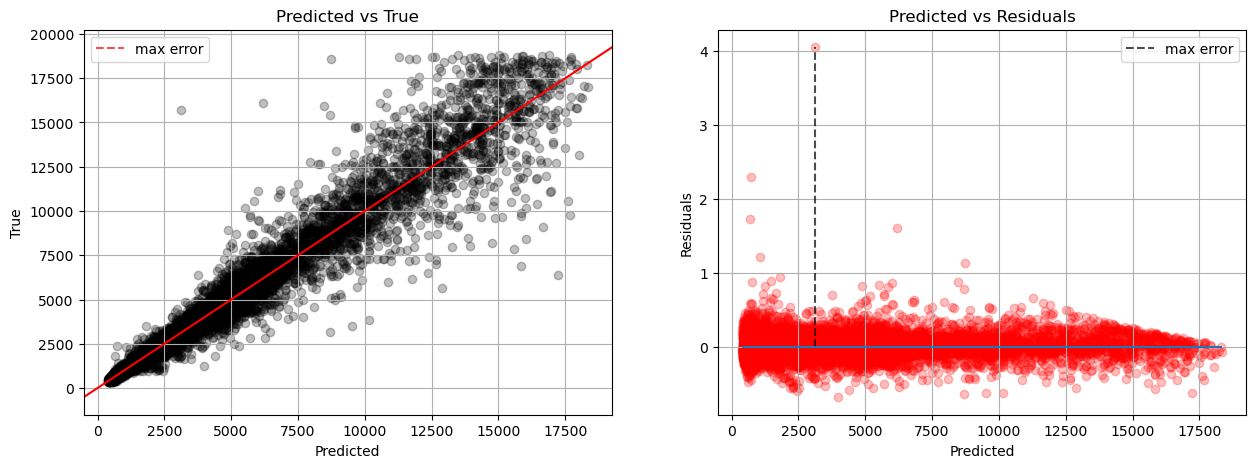

In [35]:
plot_2_error(y_test, best_knn.predict(X_test))

**SVR**

In [37]:
axis_transformer = Pipeline(steps=[
    ('missing_num', IterativeImputer(missing_values=0, max_iter=5)),
    ('scaler', StandardScaler())])

num = Pipeline(steps=[
    ('missing_num', IterativeImputer(missing_values=0, max_iter=5)),
    ('scaler', StandardScaler())])

clarity_map = [{
    'col':'clarity',##### Обратить внимание
    'mapping':{'IF':7, 'VVS1':6, 'VVS2':5, 'VS1':4, 'VS2':3, 
               'SI1':2, 'SI2':1, 'I1':0}
    }]

clarity_transformer = Pipeline(steps=[
    ('missing_num', SimpleImputer(strategy = 'most_frequent')),
    ('ce',ce.OrdinalEncoder(mapping=clarity_map)),
    ('scaler', MinMaxScaler())
    ])    
    
CT_SVR = ColumnTransformer([
        ("axis_transformer", axis_transformer, axis_features),
        ("num", num, num_features),
        # убрать быстую разряженную 
        ("cat", OneHotEncoder(sparse_output=False, drop='first'), cat_features),
        ("ordinal_map", clarity_transformer, ['clarity'])##### Обратить внимание
      ], remainder='passthrough').set_output(transform='pandas')

In [38]:
model_pipe = Pipeline([
                ('model', TransformedTargetRegressor(
                        regressor = Pipeline(steps=[
                                ('preproc', CT_SVR),
                                ('estimator', SVR())
                            ]),
                        transformer=PowerTransformer(method="box-cox"),
                        check_inverse = False)
                )])
model_pipe.fit(X_train, y_train)

Pipeline(steps=[('model',
                 TransformedTargetRegressor(check_inverse=False,
                                            regressor=Pipeline(steps=[('preproc',
                                                                       ColumnTransformer(remainder='passthrough',
                                                                                         transformers=[('axis_transformer',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         IterativeImputer(max_iter=5,
                                                                                                                                          missing_values=0)),
                                                                                                                        ('scaler',
                                                                                                                         StandardScaler())]),
                                                                                                        ['x',
                                                                                                         'y',
                                                                                                         'z']),
                                                                                                       ('num',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         Iter...
                                                                                                                      sparse_output=False),
                                                                                                        ['cut',
                                                                                                         'color']),
                                                                                                       ('ordinal_map',
                                                                                                        Pipeline(steps=[('missing_num',
                                                                                                                         SimpleImputer(strategy='most_frequent')),
                                                                                                                        ('ce',
                                                                                                                         OrdinalEncoder(mapping=[{'col': 'clarity',
                                                                                                                                                  'data_type': dtype('O'),
                                                                                                                                                  'mapping': IF      7
VVS1    6
VVS2    5
VS1     4
VS2     3
SI1     2
SI2     1
I1      0
dtype: int64}])),
                                                                                                                        ('scaler',
                                                                                                                         MinMaxScaler())]),
                                                                                                        ['clarity'])])),
                                                                      ('estimator',
                                                                       SVR())]),
                                            transformer=PowerTransformer(method='box-cox')))])

In [39]:
param_grid = [
    {'model__regressor__estimator':[SVR(kernel = 'rbf')],
     'model__regressor__estimator__gamma': [0.07, 0.1],
     'model__regressor__estimator__C': [35, 40, 30],
     'model__regressor__estimator__epsilon': [0.07, 0.1]}
]
cv = KFold(n_splits=4, shuffle=True)
scoring= make_scorer(mse_irq)


grid_2 = RandomizedSearchCV(model_pipe, param_grid, cv=cv, n_jobs=-1, scoring=scoring, refit='MSE_IRQ')
grid_2.fit(X_train, y_train)

final = grid_2.best_estimator_
final.fit(X_train, y_train)

In [42]:
y_pred_fin = final.predict(X_test)
print(mean_squared_error(y_test, y_pred_fin))
print(mse_irq(y_test, y_pred_fin))

NameError: name 'final' is not defined

In [ ]:
grid_result = pd.DataFrame(grid_2.cv_results_).sort_values(["rank_test_MSE_IRQ"])
grid_result.T

In [ ]:
pv_table=grid_result.pivot_table(index='param_model__regressor__estimator__C',columns='param_model__regressor__estimator__gamma',values='mean_test_MSE_IRQ')
pv_table_std=grid_result.pivot_table(index='param_model__regressor__estimator__C',columns='param_model__regressor__estimator__gamma',values='std_test_MSE_IRQ')
f, (ax1, ax2) = plt.subplots(1, 2,figsize=(15, 9))
sns.heatmap(pv_table, annot=True, linewidths=.5, ax=ax1)
sns.heatmap(pv_table_std, annot=True, linewidths=.5, ax=ax2);

In [ ]:
grid_2.best_params_

In [ ]:
print(mse_irq(y_test, final.predict(X_test)))
print(mean_squared_error(y_test, final.predict(X_test)))

In [ ]:
# import pickle

# # Запись модели
# with open('svc-model.pkl', 'wb') as f:
#     pickle.dump(final, f)